In [1]:
import torch
import torch.nn as nn
import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt
from lattice_boolean_analysis import LBFFromNN
from spin_lattices import KagomeLattice
from fast_boolean_analysis import fourier_expand
from misc_utils import get_abslargest_terms

2023-02-27 16:08:11.819 | DEBUG    | lattice_symmetries:__init__:49 - Initializing Haskell runtime...
2023-02-27 16:08:11.821 | DEBUG    | lattice_symmetries:__init__:51 - Initializing Chapel runtime...
2023-02-27 16:08:11.878 | DEBUG    | lattice_symmetries:__init__:53 - Setting Python exception handler...
[Debug]   [LOCALE0]   Initializing chpl_kernels ...
set_python_exception_handler ...


In [2]:
lat = KagomeLattice(width=2, height=3)

In [66]:
net = nn.Sequential(
    nn.Linear(lat.number_spins, 64),
    nn.Tanh(),
    nn.Linear(64, 1),
)

In [67]:
net(1 - 2 * torch.randint(0, 2, size=(lat.number_spins,), dtype=torch.float32))

tensor([0.1270], grad_fn=<AddBackward0>)

In [68]:
signal = LBFFromNN(lat, net, pd.Series(np.ones(2 ** lat.number_spins) / 2 ** lat.number_spins))

In [69]:
series = fourier_expand(signal)

In [70]:
terms, coeffs = get_abslargest_terms(series.coeffs, 10)

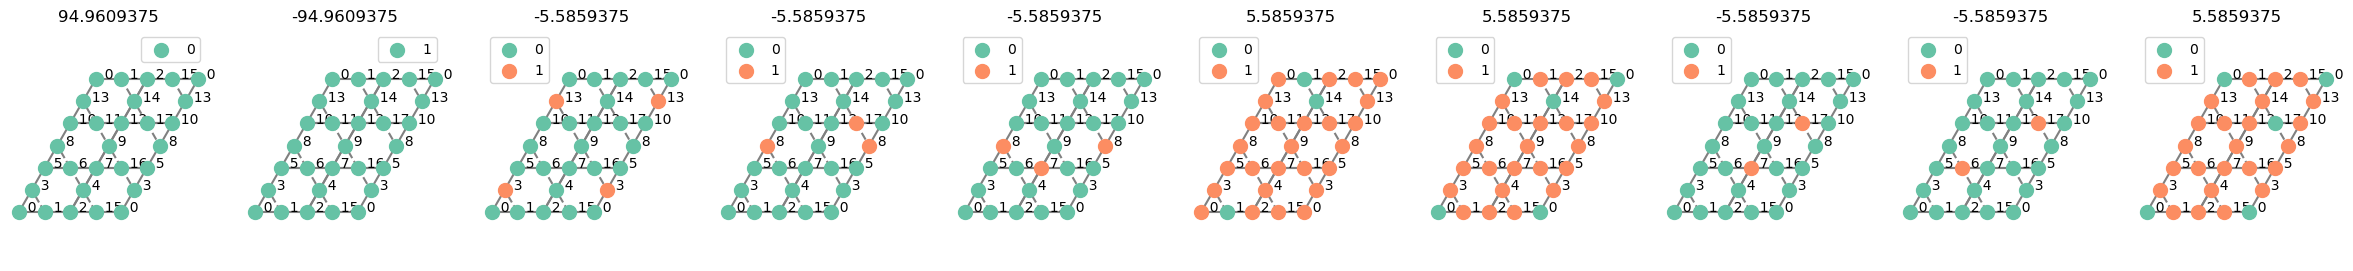

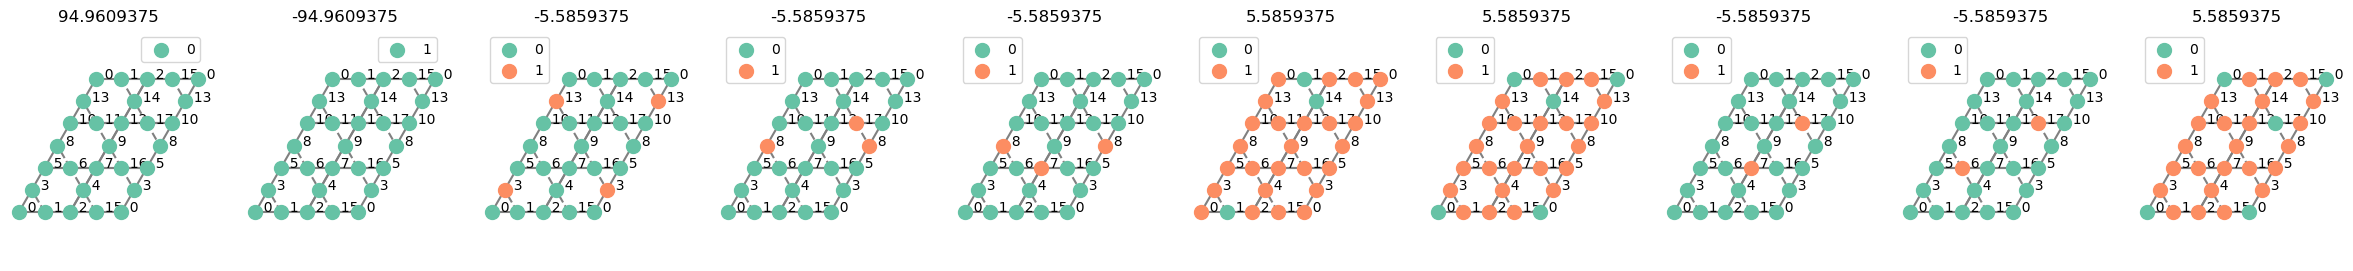

In [71]:
lat.plot_subsets(terms, coeffs)

In [9]:
series.how_many_terms_to_achieve_score(0.9, scorer="f1")

2023-02-27 16:08:38.159 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:148 - At min_terms=1, score=1.0 >= target_score=0.9, so we can achieve the target score with 1 terms


(True,
 1,
 array([0.18547058, 0.18547058, 0.18547058, ..., 0.18547058, 0.18547058,
        0.18547058]))

In [46]:
series.signal.canonical_basis.states.shape

(48620,)